Tarea 1: Setup

In [4]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# Instalar si no lo tienes: pip install "gymnasium[toy-text]"
env = gym.make("CliffWalking-v1")

# Explorar el entorno
print("Obs space:", env.observation_space)    # Discrete(48) — grid 4x12
print("Act space:", env.action_space)         # Discrete(4) — 0=UP 1=RIGHT 2=DOWN 3=LEFT
print("n estados:", env.observation_space.n)  # 48
print("n acciones:", env.action_space.n)      # 4

obs, info = env.reset(seed=42)
print(f"Estado inicial: {obs}")               # 36 = esquina inf-izquierda
obs2, r, done, _, _ = env.step(1)             #  derecha
print(f"Paso a derecha: s'={obs2}, r={r}")    # r=-1 (normal) o r=-100 (cliff)


Obs space: Discrete(48)
Act space: Discrete(4)
n estados: 48
n acciones: 4
Estado inicial: 36
Paso a derecha: s'=36, r=-100


In [5]:
def run_episode(env, policy_fn, max_steps=500, seed=None):
    """Corre un episodio. Retorna lista [(s,a,r)] y reward total."""
    obs, _ = env.reset(seed=seed)
    episode, total_r = [], 0
    for _ in range(max_steps):
        action = policy_fn(obs)
        obs_next, r, done, truncated, _ = env.step(action)
        episode.append((obs, action, r))
        total_r += r;  obs = obs_next
        if done or truncated: break
    return episode, total_r

# Baseline: politica aleatoria
random_rewards = [run_episode(env, lambda s: env.action_space.sample())[1]
                  for _ in range(500)]
print(f"Reward medio (aleatorio): {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
#print (random_rewards)


Reward medio (aleatorio): -5052.8 ± 1227.5
[-5747, -3767, -4856, -4163, -5648, -5153, -6440, -3668, -4559, -5153, -5846, -5648, -5945, -5747, -5153, -5351, -5846, -6737, -6044, -5153, -5450, -3970, -5351, -4460, -7034, -5252, -5450, -5747, -5054, -1720, -978, -4460, -5648, -4856, -6341, -5153, -5351, -4460, -5153, -5648, -6539, -6539, -3965, -4064, -4856, -5351, -4361, -5846, -5945, -5351, -5945, -5945, -4955, -4361, -5549, -4658, -4361, -4658, -6539, -4460, -6539, -3668, -3173, -4361, -5747, -5153, -3259, -6737, -3173, -4658, -4262, -2480, -3668, -5648, -4361, -6242, -3569, -4559, -4856, -6440, -5747, -5846, -6539, -5846, -7331, -3569, -3866, -4658, -6737, -3866, -5945, -3569, -4856, -4064, -3195, -5846, -4658, -5945, -4559, -4757, -5846, -3668, -5549, -6242, -5252, -5747, -6638, -4955, -5054, -4658, -3866, -4361, -3965, -3569, -5153, -5747, -6341, -3470, -5747, -5351, -5153, -3470, -5351, -6737, -2582, -4856, -5252, -5458, -4658, -8816, -5549, -4163, -5747, -5846, -6440, -5252, -5054

Pregunta adicional: En nuestra función run_episode de la T1, utilizamos env.action_space.sample() para definir la política de línea base. Sabiendo que el entorno tiene 4 acciones posibles y que la recompensa media resultante es de aproximadamente -3247, analiza el código del bucle: ¿Por qué la desviación estándar es tan grande matemáticamente? Si cada paso aleatorio tiene un 25% de probabilidad de ser el correcto, ¿qué nos dice este resultado empírico sobre la eficiencia de la búsqueda aleatoria en entornos con penalizaciones terminales severas (como el -100 del acantilado )?

Tarea 2 : Sarsa
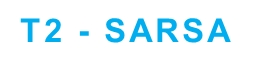
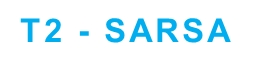

In [7]:
nS = env.observation_space.n   # 48
nA = env.action_space.n        # 4

# Tabla Q como tensor PyTorch (permite GPU si se desea)
Q_sarsa = torch.zeros(nS, nA, dtype=torch.float32)

def epsilon_greedy(Q, state, epsilon=0.1):
    """Selecciona accion ε-greedy. Retorna int."""
    if torch.rand(1).item() < epsilon:
        return torch.randint(nA, (1,)).item()       # explorar
    return Q[state].argmax().item()                  # explotar

def sarsa(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """SARSA on-policy. Retorna Q y lista de rewards por episodio."""
    Q = torch.zeros(nS, nA, dtype=torch.float32)
    episode_rewards = []

    for ep in range(n_episodes):
        s, _ = env.reset(seed=ep)
        a = epsilon_greedy(Q, s, epsilon)            # SARSA: elige a antes del loop
        total_r = 0

        while True:
            s_next, r, done, truncated, _ = env.step(a)
            a_next = epsilon_greedy(Q, s_next, epsilon)  # SARSA: elige a' con ε-greedy
            # Actualizacion SARSA
            td_target = r + gamma * Q[s_next, a_next] * (0 if done else 1)
            td_error  = td_target - Q[s, a]
            Q[s, a]  += alpha * td_error
            s, a = s_next, a_next
            total_r += r
            if done or truncated: break

        episode_rewards.append(total_r)
    return Q, episode_rewards

Entrenando SARSA...
Episodio 500 reward: -18


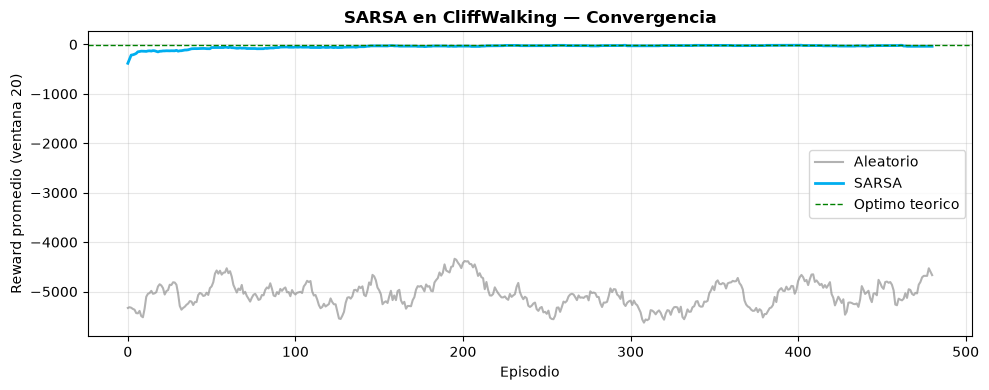

In [8]:
# Ejecutar SARSA
print("Entrenando SARSA...")
Q_sarsa, rewards_sarsa = sarsa(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1)
print(f"Episodio 500 reward: {rewards_sarsa[-1]}")

# Media movil para suavizar curva (ventana 20 episodios)
def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(moving_avg(random_rewards[:500]), color='gray', alpha=0.6, label='Aleatorio')
ax.plot(moving_avg(rewards_sarsa),        color='#00AEEF', linewidth=2, label='SARSA')
ax.axhline(-13, color='green', linestyle='--', linewidth=1, label='Optimo teorico')
ax.set_xlabel('Episodio'); ax.set_ylabel('Reward promedio (ventana 20)')
ax.set_title('SARSA en CliffWalking — Convergencia', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


Pregunta adicional: Revisa detenidamente el bucle de entrenamiento en su función sarsa. Notarás que instanciamos la variable a antes de entrar al bucle while y luego instanciamos una nueva variable a_next llamando a la función epsilon_greedy dentro del bucle. A nivel estricto de código, ¿por qué el cálculo de td_target  depende obligatoriamente de pasar ese a_next recién calculado al tensor Q[s_next, a_next] en lugar de simplemente buscar el valor más alto disponible para ese estado?

Tarea 3 :  Q Learning
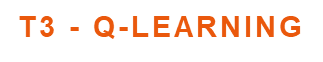

In [11]:
def q_learning(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Q-Learning off-policy. Retorna Q y lista de rewards por episodio."""
    Q = torch.zeros(nS, nA, dtype=torch.float32)
    episode_rewards = []

    for ep in range(n_episodes):
        s, _ = env.reset(seed=ep)
        total_r = 0

        while True:
            a = epsilon_greedy(Q, s, epsilon)        # behavior policy: ε-greedy
            s_next, r, done, truncated, _ = env.step(a)

            # Actualizacion Q-Learning — diferencia: max en lugar de Q[s',a']
            td_target = r + gamma * Q[s_next].max() * (0 if done else 1)
            #                              ^^^
            #         Q-Learning: max sobre TODAS las acciones (target = greedy)
            #         SARSA usaria: Q[s_next, a_next]  (a_next = ε-greedy)
            td_error  = td_target - Q[s, a]
            Q[s, a]  += alpha * td_error
            s = s_next;  total_r += r
            if done or truncated: break

        episode_rewards.append(total_r)
    return Q, episode_rewards

print("Entrenando Q-Learning...")
Q_ql, rewards_ql = q_learning(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1)
print(f"Episodio 500 reward: {rewards_ql[-1]}")


Entrenando Q-Learning...
Episodio 500 reward: -120


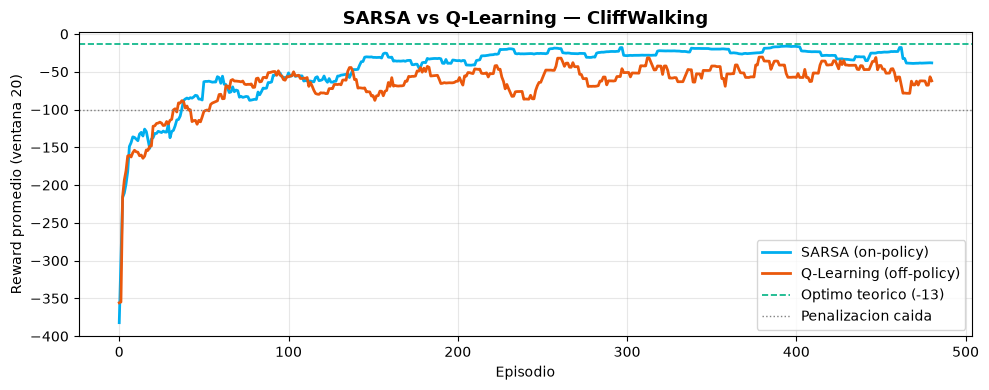

SARSA    — media ultimos 50: -28.7
Q-Learn  — media ultimos 50: -55.1


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(moving_avg(rewards_sarsa), color='#00AEEF', linewidth=2, label='SARSA (on-policy)')
ax.plot(moving_avg(rewards_ql),    color='#EA580C', linewidth=2, label='Q-Learning (off-policy)')
ax.axhline(-13, color='#00B383', linestyle='--', linewidth=1.2, label='Optimo teorico (-13)')
ax.axhline(-100, color='gray', linestyle=':', linewidth=1, label='Penalizacion caida')
ax.set_xlabel('Episodio'); ax.set_ylabel('Reward promedio (ventana 20)')
ax.set_title('SARSA vs Q-Learning — CliffWalking', fontweight='bold', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Estadisticas finales (ultimos 50 episodios)
print(f"SARSA    — media ultimos 50: {np.mean(rewards_sarsa[-50:]):.1f}")
print(f"Q-Learn  — media ultimos 50: {np.mean(rewards_ql[-50:]):.1f}")


Tarea 4:  Trayectorias
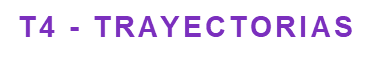

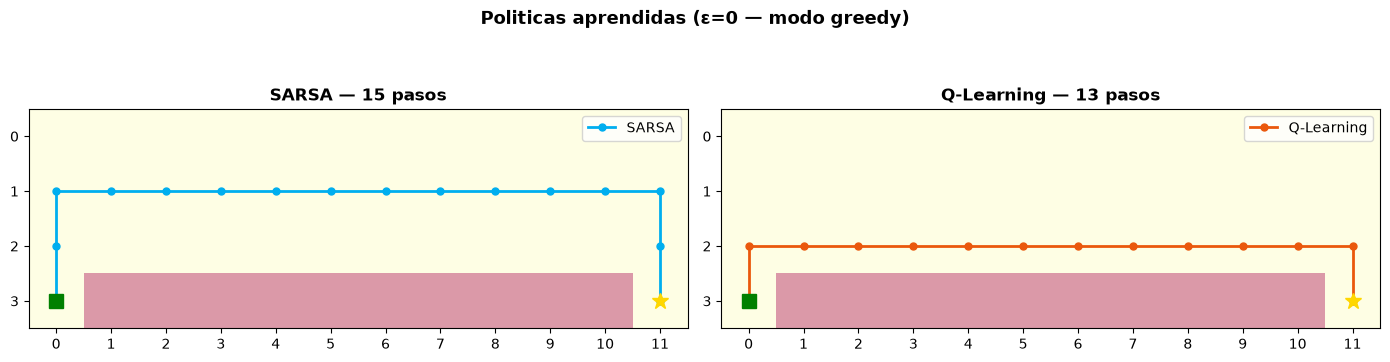

In [13]:
def get_trajectory(Q, env, epsilon=0.0, max_steps=200, seed=0):
    """Extrae trayectoria greedy (ε=0) o ε-greedy."""
    states = []
    s, _ = env.reset(seed=seed)
    states.append(s)
    for _ in range(max_steps):
        a = epsilon_greedy(Q, s, epsilon)
        s, r, done, truncated, _ = env.step(a)
        states.append(s)
        if done or truncated: break
    return states

def plot_trajectories(traj_sarsa, traj_ql, title="Trayectorias"):
    grid = np.zeros((4, 12))
    grid[3, 1:11] = -1   # cliff en rojo
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, traj, name, color in zip(
        axes, [traj_sarsa, traj_ql], ["SARSA", "Q-Learning"], ["#00AEEF", "#EA580C"]
    ):
        im = ax.imshow(grid, cmap='RdYlGn', vmin=-1, vmax=1, alpha=0.4)
        rows = [s // 12 for s in traj]; cols = [s % 12 for s in traj]
        ax.plot(cols, rows, '-o', color=color, linewidth=2, markersize=5, label=name)
        ax.plot(cols[0], rows[0], 's', color='green', markersize=10)   # inicio
        ax.plot(cols[-1], rows[-1], '*', color='gold', markersize=12)  # fin
        ax.set_title(f"{name} — {len(traj)-1} pasos", fontweight='bold')
        ax.set_xticks(range(12)); ax.set_yticks(range(4)); ax.legend()
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

traj_s = get_trajectory(Q_sarsa, env, epsilon=0.0)
traj_q = get_trajectory(Q_ql,    env, epsilon=0.0)
plot_trajectories(traj_s, traj_q, "Politicas aprendidas (ε=0 — modo greedy)")
